# MSM vs GMM — VaR Backtest Comparison

Comparison of the **MarkovSwitchingVaR** model against the **GaussianMixtureVaR** baseline for Value-at-Risk prediction on the S&P 500, across 2 / 3 states and α = 5% / 1%.

In [1]:
%matplotlib inline
import os
import re
from pathlib import Path

# --- All hardcoded configuration lives here (top of the notebook) ---
PROJECT_ROOT = "/home/mrdelrus/Documents/projects/markov-switching-model"
# Make cached price history resolvable regardless of the working directory.
os.environ["MS_VAR_DATA_DIR"] = PROJECT_ROOT

RESULTS_DIR = Path(PROJECT_ROOT) / "outputs" / "results"
FEATURES_DIR = Path(PROJECT_ROOT) / "outputs" / "features"

BEGIN = "2010-01-01"   # inclusive; first year is warm-up
END = "2026-01-01"     # exclusive
WINDOW = 252           # rolling window, ~1 trading year

ALPHAS = [0.05, 0.01]
N_COMPONENTS = 2       # focus of the difference analysis
MODELS = ["msm", "gmm"]
TESTS = ["binomial", "independence_simple"]  # the two simplest tests
TEST_COLS = [
    "binomial",
    "independence_simple",
    "kupiec",
    "christoffersen_independence",
    "christoffersen_conditional",
]

# Prefer recognisable, liquid names when several example stocks qualify.
PREFERRED_TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "JPM", "JNJ",
    "XOM", "WMT", "PG", "KO", "V", "MA", "HD", "BAC", "CVX",
]

# Plot styling (matches the project's plotting module).
RET_COLOR = "#555555"
MSM_COLOR = "#e06c00"
GMM_COLOR = "#9b30d9"
ZERO_COLOR = "#aaaaaa"
FIGSIZE = (16, 6)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from ms_var_prediction.pipeline import features as fs
from ms_var_prediction.pipeline.data import cached_history
from ms_var_prediction.utils import prices_to_returns

/home/mrdelrus/Documents/projects/markov-switching-model/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

- **Source:** daily close prices from **Yahoo Finance** (`yfinance`), cached locally under `yfinance_cache/` to avoid re-downloading.
- **Universe:** **S&P 500 constituents** (503 symbols from `constituents.csv`). Tickers without usable price history for a given year are skipped automatically; **498 / 503** produced results over the full period.
- **Period:** **2010-01-01 → 2026-01-01** (end exclusive). The first calendar year (2010) is reserved as **warm-up** to seed the initial rolling window, so the backtest covers **2011–2025 (15 full years)**.
- **Returns:** daily **log returns**.
- **Rolling window:** **252 trading days** (~1 year). Each day the model is refit on the trailing window and predicts the next day's VaR.
- **VaR:** the α-quantile of the fitted mixture distribution, found by CDF bisection.
- **Models:** `MarkovSwitchingVaR` (N-state Gaussian hidden Markov model, fit by MLE) and `GaussianMixtureVaR` (scikit-learn GMM), with **2** and **3** states / components.
- **Backtests (per stock):** binomial (unconditional coverage), simple independence, Kupiec, Christoffersen independence, Christoffersen conditional coverage. A test **passes** at the 5% significance level.

## Aggregate results

Fraction of S&P 500 stocks that **pass** each test, by model, number of states and α.

In [2]:
rows = []
for f in sorted(RESULTS_DIR.glob("*.csv")):
    m = re.match(r"(\w+)_nc(\d+)_w\d+_.*_(0\.\d+)_\w+\.csv", f.name)
    if m is None:
        continue
    model, nc, alpha = m.group(1).upper(), int(m.group(2)), float(m.group(3))
    df = pd.read_csv(f)
    rec = {"model": model, "states": nc, "alpha": alpha}
    rec.update({t: float(df[t].iloc[0]) for t in TEST_COLS})
    rows.append(rec)

table = (
    pd.DataFrame(rows)
    .set_index(["model", "states", "alpha"])
    .sort_index()
    .round(3)
)
table

binomial  independence_simple  kupiec  \
model states alpha                                          
GMM   2      0.01      0.588                0.430   0.645   
             0.05      0.928                0.129   0.928   
      3      0.01      0.596                0.430   0.677   
             0.05      0.948                0.137   0.948   
MSM   2      0.01      0.486                0.528   0.554   
             0.05      0.886                0.755   0.884   
      3      0.01      0.564                0.751   0.610   
             0.05      0.689                0.920   0.691   

                    christoffersen_independence  christoffersen_conditional  
model states alpha                                                           
GMM   2      0.01                         0.432                       0.357  
             0.05                         0.129                       0.159  
      3      0.01                         0.432                       0.373  
             0.05                         0.137                       0.183  
MSM   2      0.01                         0.532                       0.386  
             0.05                         0.741                       0.741  
      3      0.01                         0.755                       0.560  
             0.05                         0.871                       0.691

## Example of differences

For **n_components = 2** we look at the two simplest tests — **binomial** and **independence (simple)** — at **α = 0.05** and **α = 0.01**. For every (α, test) we look for a stock that is **passed by one model but failed by the other**, in both directions (MSM-passes and GMM-passes). That gives up to **2 (α) × 2 (test) × 2 (winning model) = 8** plots. If no such stock exists for a combination (one model is never strictly better there), that plot is skipped.

Each plot shows the stock's daily log returns together with the predicted VaR of **both** models, so the difference in tail behaviour is visible.

In [3]:
def load_model_features(model, nc):
    paths = sorted(FEATURES_DIR.glob(f"{model}_nc{nc}_w{WINDOW}_*_default.csv"))
    return pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)

# Load the per-window fitted parameters for both n=2 models (alpha-independent).
feat = {m: load_model_features(m, N_COMPONENTS) for m in MODELS}
for m in MODELS:
    print(f"{m}: {len(feat[m]):,} window-rows, {feat[m]['ticker'].nunique()} tickers")

msm: 1,771,072 window-rows, 498 tickers
gmm: 1,771,072 window-rows, 498 tickers


In [4]:
# Per-stock pass/fail (0/1) table for each (model, alpha).
per_stock = {}
for m in MODELS:
    for a in ALPHAS:
        preds = fs.predict_var(feat[m], m, a)
        ps, _ = fs.backtest_predictions(preds, a)
        per_stock[(m, a)] = ps
        print(f"{m} alpha={a}: {ps.shape[0]} stocks backtested")

msm alpha=0.05: 498 stocks backtested


msm alpha=0.01: 498 stocks backtested


gmm alpha=0.05: 498 stocks backtested


gmm alpha=0.01: 498 stocks backtested


In [5]:
def pick_example(candidates):
    """Prefer a recognisable ticker, else the first alphabetically."""
    for p in PREFERRED_TICKERS:
        if p in candidates:
            return p
    return sorted(candidates)[0] if candidates else None

examples = {}
for a in ALPHAS:
    msm_ps, gmm_ps = per_stock[("msm", a)], per_stock[("gmm", a)]
    common = msm_ps.index.intersection(gmm_ps.index)
    for test in TESTS:
        msm_only = [t for t in common
                    if msm_ps.loc[t, test] == 1 and gmm_ps.loc[t, test] == 0]
        gmm_only = [t for t in common
                    if gmm_ps.loc[t, test] == 1 and msm_ps.loc[t, test] == 0]
        examples[(a, test, "MSM")] = pick_example(msm_only)
        examples[(a, test, "GMM")] = pick_example(gmm_only)

print("Chosen example stocks (None = no qualifying stock, plot skipped):")
for k, v in examples.items():
    print(f"  alpha={k[0]:<4} {k[1]:<20} {k[2]}-passes -> {v}")

Chosen example stocks (None = no qualifying stock, plot skipped):
  alpha=0.05 binomial             MSM-passes -> AAPL
  alpha=0.05 binomial             GMM-passes -> ABBV
  alpha=0.05 independence_simple  MSM-passes -> AAPL
  alpha=0.05 independence_simple  GMM-passes -> SW
  alpha=0.01 binomial             MSM-passes -> MSFT
  alpha=0.01 binomial             GMM-passes -> JPM
  alpha=0.01 independence_simple  MSM-passes -> MSFT
  alpha=0.01 independence_simple  GMM-passes -> AMCR


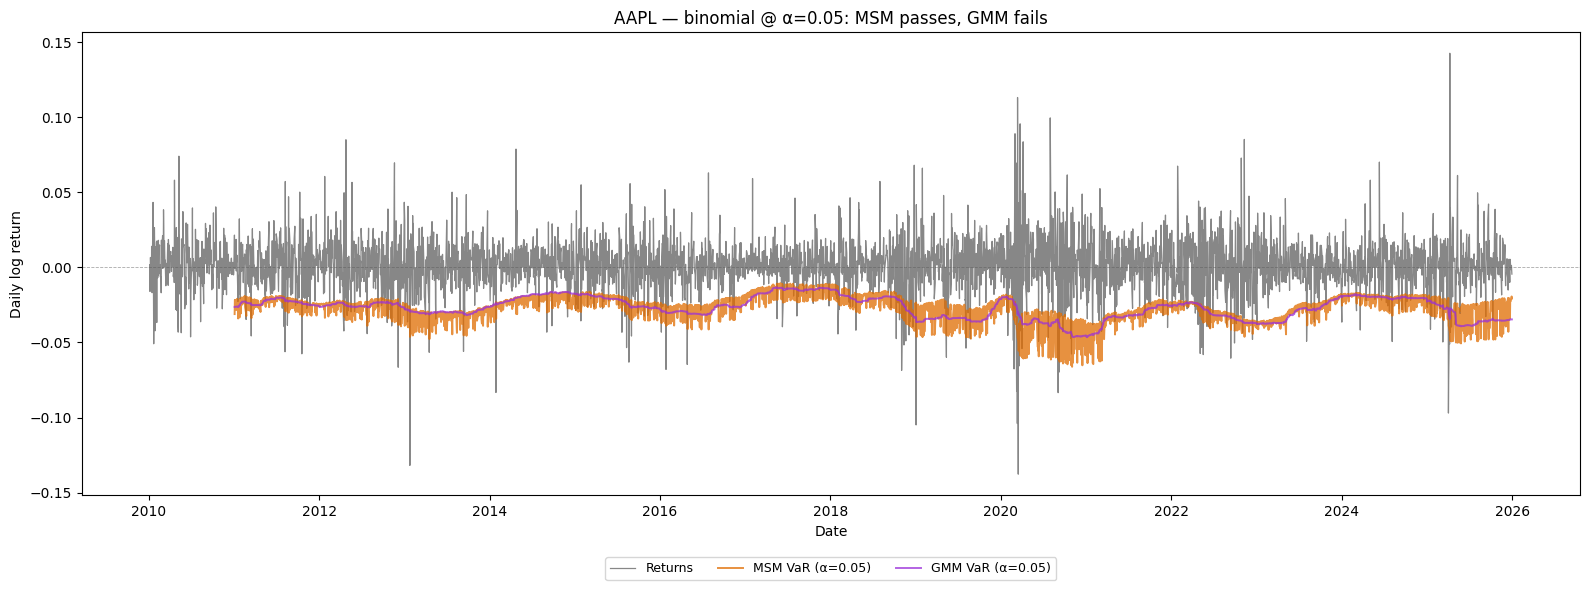

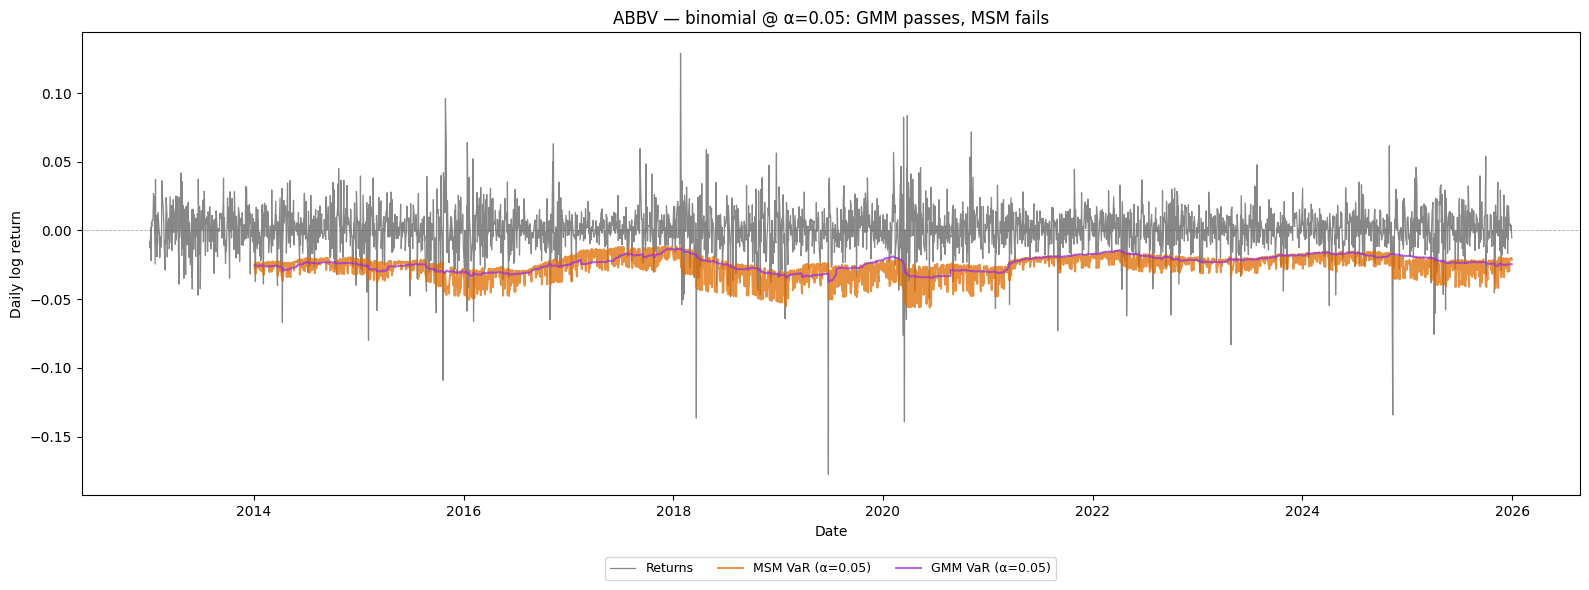

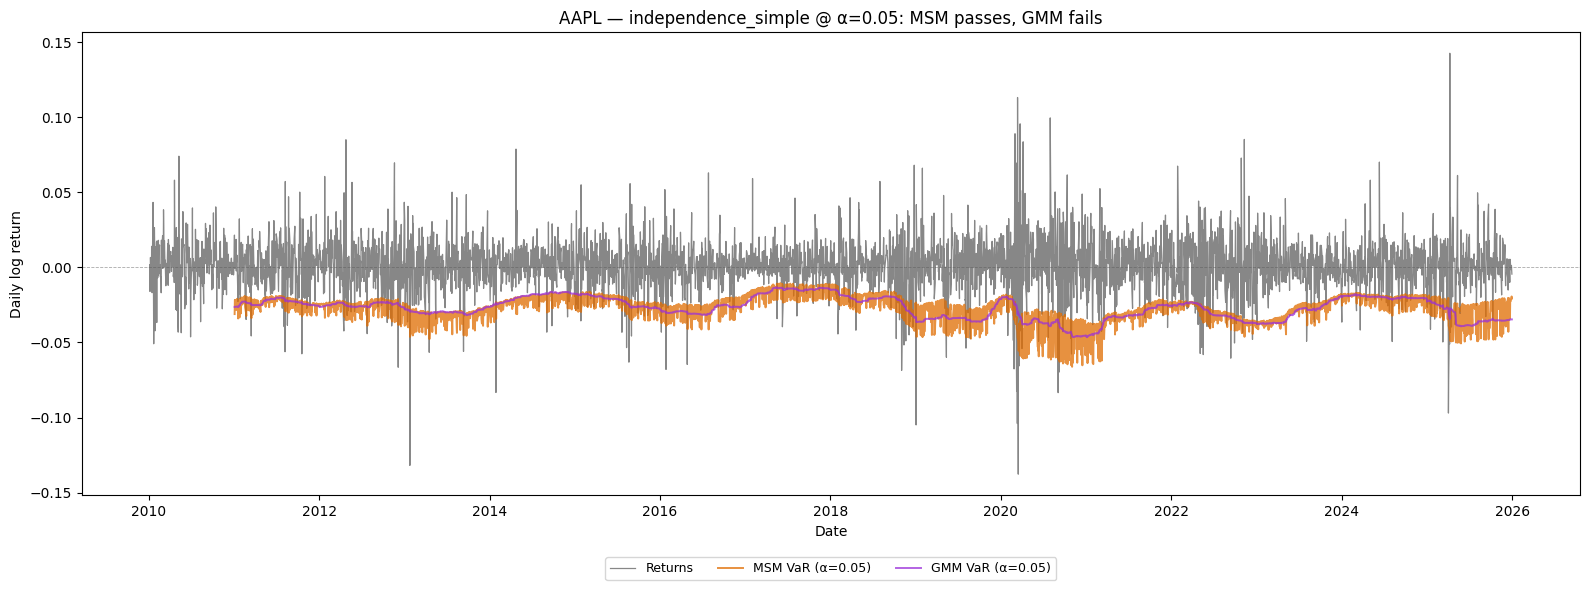

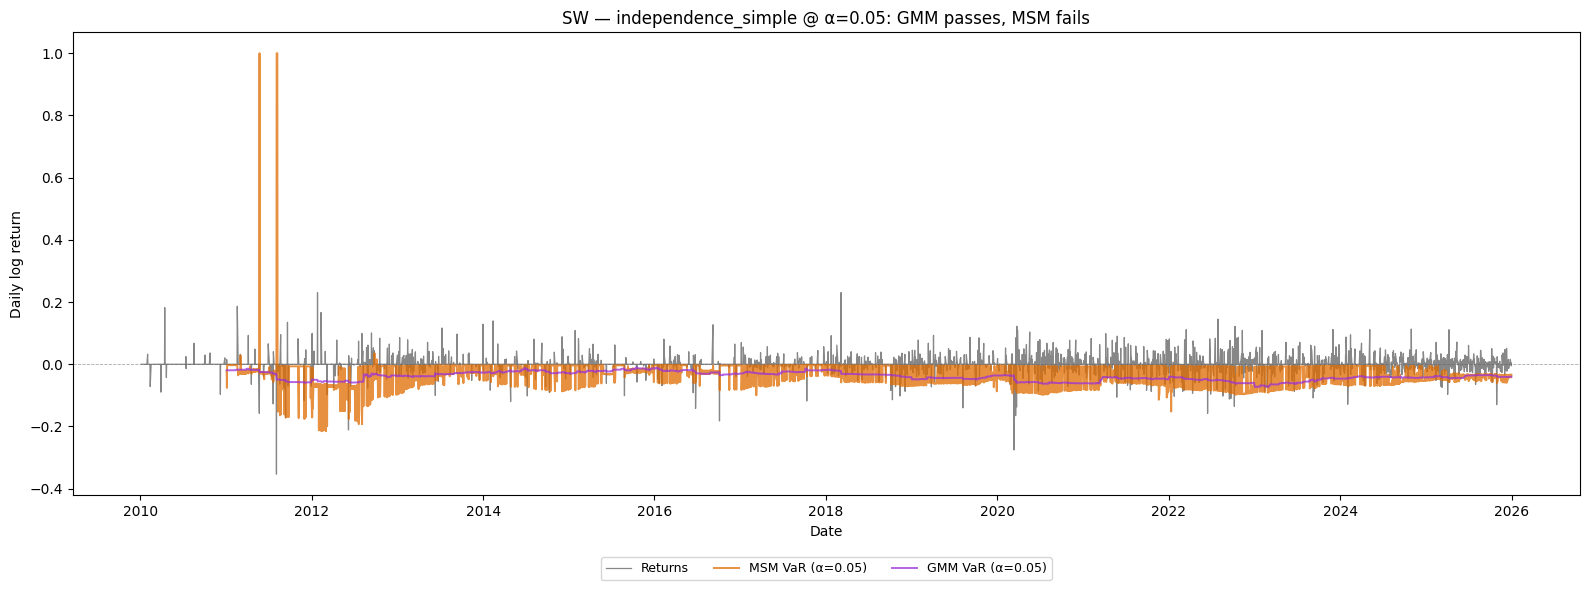

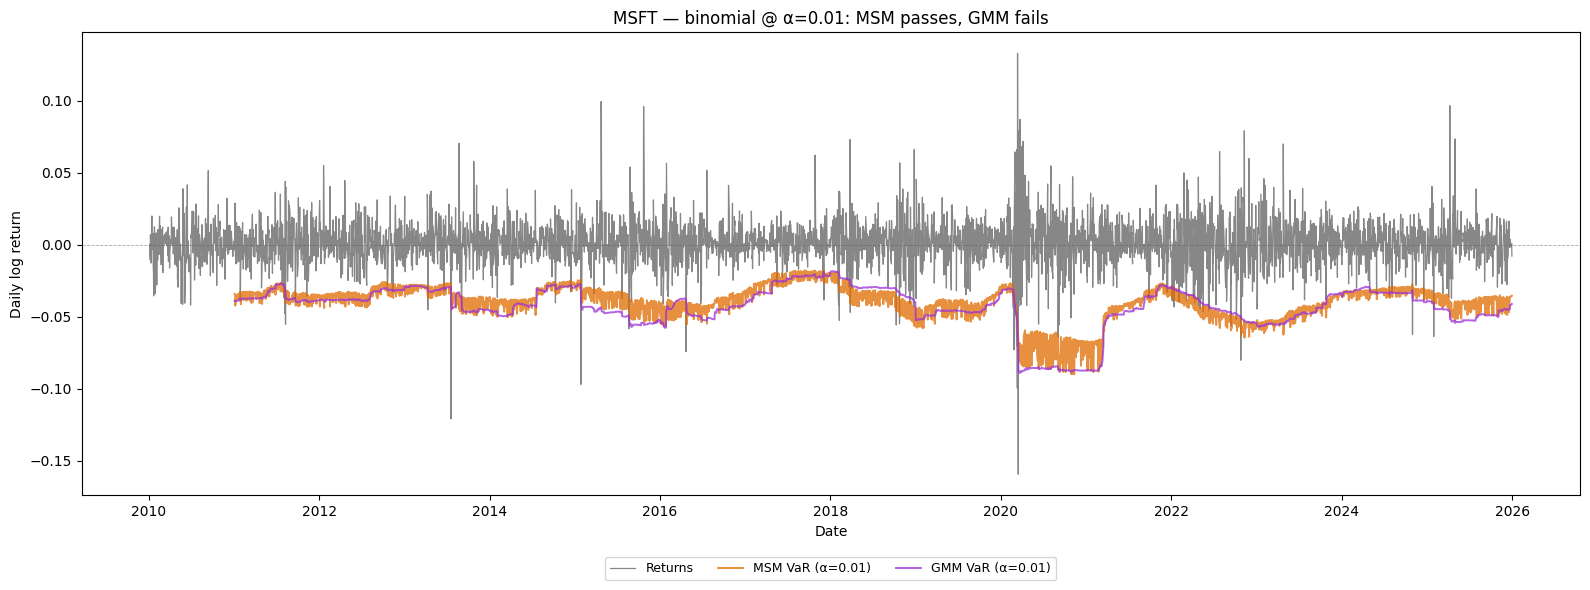

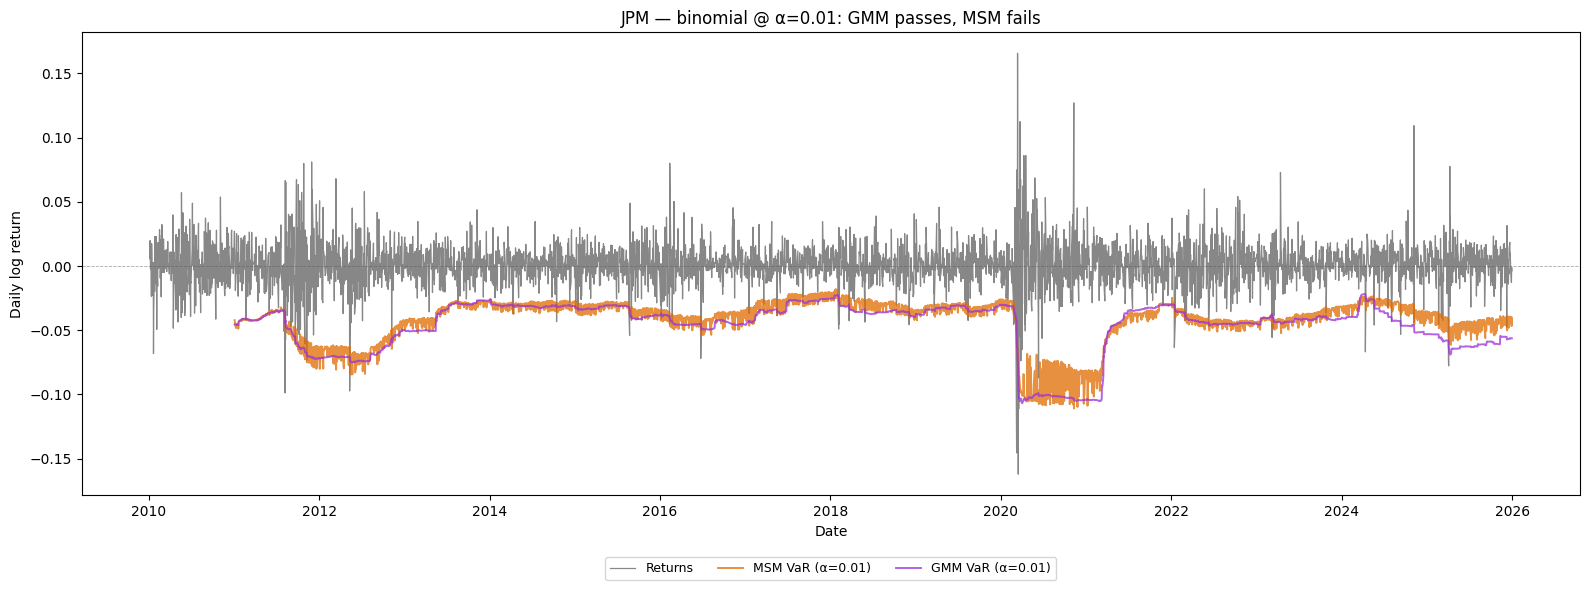

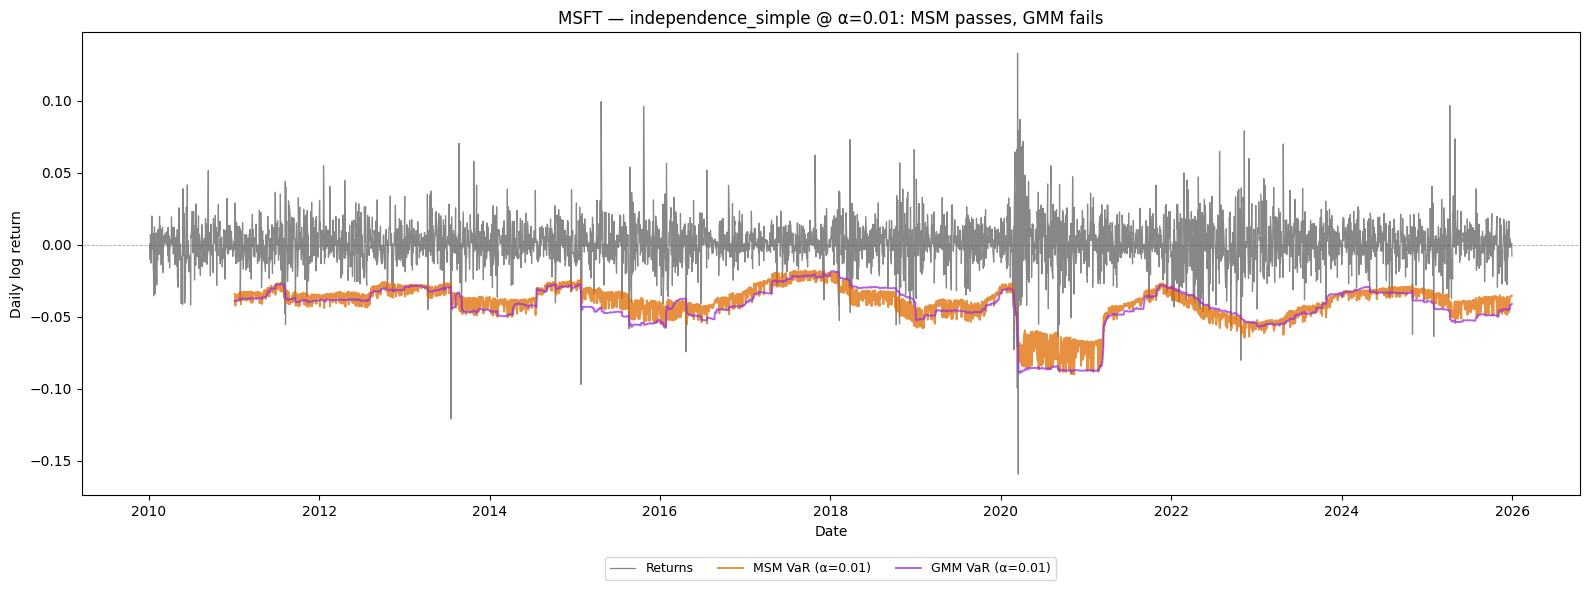

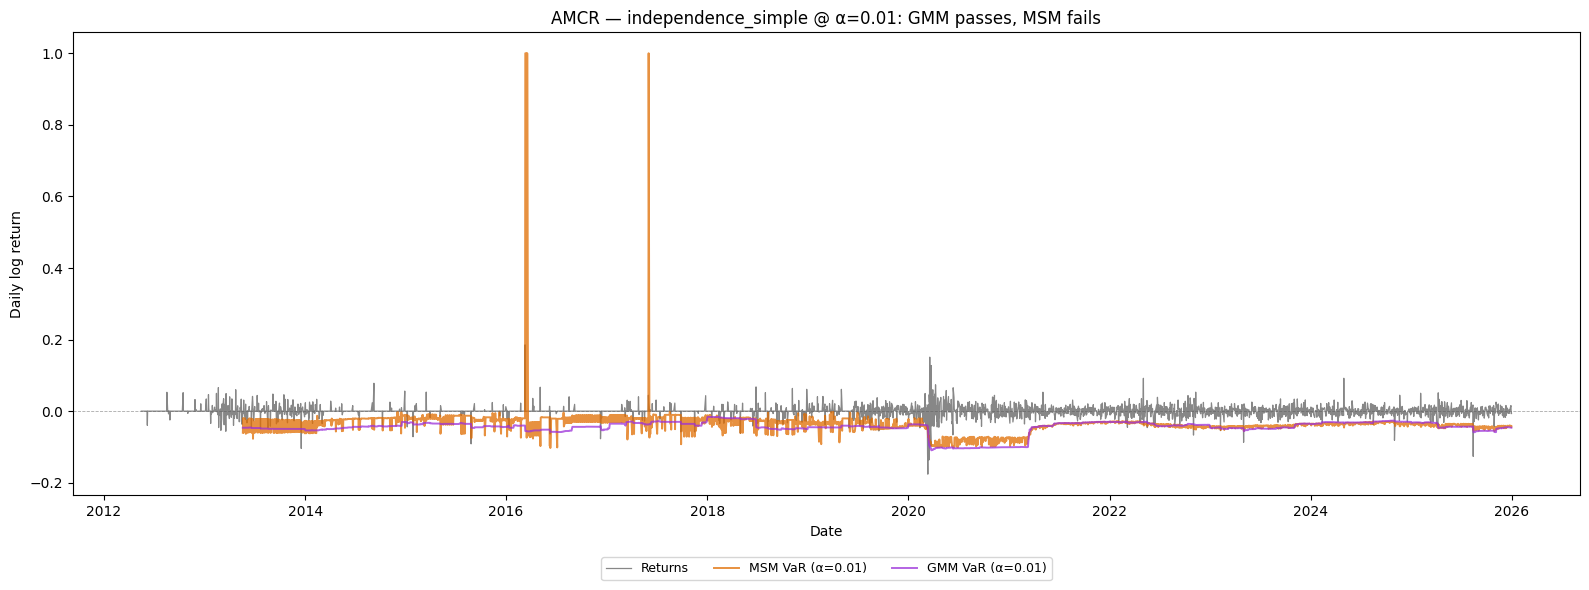

In [6]:
def ticker_returns(tk):
    prices = cached_history(yf.Ticker(tk), BEGIN, END)["Close"].dropna()
    return pd.Series(prices_to_returns(prices), index=prices.index[1:])

def ticker_var(tk, model, alpha):
    rows = feat[model][feat[model]["ticker"] == tk]
    return fs.predict_var(rows, model, alpha)

def plot_difference(tk, alpha, test, winner):
    loser = "GMM" if winner == "MSM" else "MSM"
    rets = ticker_returns(tk)
    mv = ticker_var(tk, "msm", alpha)
    gv = ticker_var(tk, "gmm", alpha)
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(rets.index, rets.to_numpy(), color=RET_COLOR, alpha=0.7,
            linewidth=0.9, label="Returns", zorder=2)
    ax.plot(pd.to_datetime(mv["date"]), mv["var"], color=MSM_COLOR, alpha=0.75,
            linewidth=1.4, label=f"MSM VaR (α={alpha:.2f})", zorder=3)
    ax.plot(pd.to_datetime(gv["date"]), gv["var"], color=GMM_COLOR, alpha=0.75,
            linewidth=1.4, label=f"GMM VaR (α={alpha:.2f})", zorder=3)
    ax.axhline(0, color=ZERO_COLOR, linewidth=0.6, linestyle="--", zorder=1)
    ax.set_title(
        f"{tk} — {test} @ α={alpha:.2f}: {winner} passes, {loser} fails",
        fontsize=12,
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Daily log return")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3,
              fontsize=9)
    fig.tight_layout()
    plt.show()

for a in ALPHAS:
    for test in TESTS:
        for winner in ["MSM", "GMM"]:
            tk = examples[(a, test, winner)]
            if tk is None:
                print(f"skipped: alpha={a} {test} {winner}-passes (no qualifying stock)")
                continue
            plot_difference(tk, a, test, winner)